# XGBoost + SHAP Analysis - ASD

**Author:** Ria Martins

**Description:** County-level ASD prevalence modeled using XGBoost with Recursive Feature Elimination (RFE) and SHAP-based interpretation.

**Pipeline:**
1. Load and prepare data (logit-transform the outcome)
2. Hyperparameter tuning (RandomizedSearchCV, 5-fold)
3. RFE down to 50 features
4. 5-fold CV evaluation on logit scale
5. Final model fit + SHAP values
6. Top 12 SHAP features for reporting
7. Plots: bar, beeswarm, PDP, dependence
8. County-level top SHAP drivers

**Notes:**
- ASD outcome is logit-transformed
- Feature selection is not nested within CV
- SHAP reflects in-sample explanations


In [1]:
# 1. Imports

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# 2. Load & prepare data

DATA_PATH = "/content/Autism + Environmental.csv"
TARGET_COL = "ASD_PREV_MEAN"

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

# Fix FIPS column header
if "﻿FIPS" in df.columns:
    df = df.rename(columns={"﻿FIPS": "FIPS"})

print("Raw shape:", df.shape)
print("First columns:", df.columns[:10].tolist())



Raw shape: (3144, 140)
First columns: ['ï»¿FIPS', 'ASD_PREV_MEAN', 'Particulate Matter <10um', 'Particulate Matter <2.5 um', 'Ozone (O3) ', 'Sulfur Dioxide (SO2)', 'Nitrogen Dioxide (NO2)', 'Carbon Monoxide', 'Ethylene dibromide (Air)', 'Formaldehyde ']


In [4]:
# 3. Prepare outcome (raw % → proportion → logit)

# Strip "%", commas, then convert to numeric
y_pct = (
    df[TARGET_COL]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
y_pct = pd.to_numeric(y_pct, errors="coerce")

# Keep only valid rows
valid_idx = y_pct.notna()
df = df.loc[valid_idx].copy()
y_pct = y_pct.loc[valid_idx].copy()

# Proportion
y_prop = y_pct / 100.0

# Logit transform (clip to avoid log(0))
eps = 1e-6
y_prop_clip = np.clip(y_prop, eps, 1 - eps)
y_logit = np.log(y_prop_clip / (1 - y_prop_clip))

print(f"Mean ASD prevalence (%):          {y_pct.mean():.4f}")
print(f"Mean ASD prevalence (proportion): {y_prop.mean():.4f}")
print(f"Mean logit ASD prevalence:        {y_logit.mean():.4f}")

Mean ASD prevalence (%):          2.5583
Mean ASD prevalence (proportion): 0.0256
Mean logit ASD prevalence:        -3.6799


In [5]:
# 4. Prepare predictors

drop_cols = [TARGET_COL, "FIPS", "Counties"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").copy()

# Ensure numeric + simple median imputation
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# Clean column names
X.columns = (
    X.columns
    .str.replace(r"[^A-Za-z0-9_()]+", "_", regex=True)
    .str.strip("_")
)

print("X shape:", X.shape)

X shape: (3143, 139)


In [6]:
# 5. Hyperparameter tuning (RandomizedSearchCV)

cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    "n_estimators":     [300, 500, 800, 1200, 1500],
    "max_depth":        [2, 3, 4, 5, 6, 8],
    "learning_rate":    [0.01, 0.02, 0.03, 0.05, 0.1],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma":            [0, 0.01, 0.1, 0.3, 1, 2],
    "reg_alpha":        [0, 0.01, 0.1, 1, 5],
    "reg_lambda":       [0.1, 1, 5, 10, 20],
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=60,
    scoring="r2",
    cv=cv5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y_logit)
best_params = search.best_params_
print("Best params:", best_params)

best_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 5, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.01, 'colsample_bytree': 0.5}


In [7]:
# 6. Recursive Feature Elimination (RFE) → 50 features

def rfe_xgb(model, X, y, target_n=50, drop_frac=0.10):
    """Iteratively drop the lowest-importance features until target_50 remain."""
    features = list(X.columns)

    while len(features) > target_n:
        model.fit(X[features], y)

        importances = pd.Series(
            model.feature_importances_, index=features
        ).sort_values()

        drop_n = max(1, int(len(features) * drop_frac))
        drop_feats = importances.index[:drop_n].tolist()
        features = [f for f in features if f not in drop_feats]

    return features


selected_features_50 = rfe_xgb(best_model, X, y_logit, target_n=50)
print("RFE selected:", len(selected_features_50), "features")

RFE selected: 47 features


In [8]:
# 7. 5-fold CV evaluation on logit scale

rmse_scores_logit = -cross_val_score(
    best_model, X[selected_features_50], y_logit,
    scoring="neg_root_mean_squared_error", cv=cv5, n_jobs=-1,
)

r2_scores_logit = cross_val_score(
    best_model, X[selected_features_50], y_logit,
    scoring="r2", cv=cv5, n_jobs=-1,
)

print("ASD logit-transformed XGBoost-RFE (50 features)")
print(f"RMSE (logit scale): {rmse_scores_logit.mean():.4f} ± {rmse_scores_logit.std():.4f}")
print(f"R²:                 {r2_scores_logit.mean():.4f} ± {r2_scores_logit.std():.4f}")

ASD logit-transformed XGBoost-RFE (50 features)
RMSE (logit scale): 0.2714 ± 0.0921
R²:                 0.2293 ± 0.0864


In [9]:
# 8. Fit final model on full data (for SHAP and PDP)

final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

X_final = X[selected_features_50].copy()
y_final = y_logit.copy()

final_model.fit(X_final, y_final)
print("Final model fitted on", X_final.shape)

Final model fitted on (3143, 47)


In [10]:
# 9. SHAP values + ranking

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_final)

shap_importance = pd.DataFrame({
    "feature": X_final.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 12 SHAP features:")
print(shap_importance.head(12))

Top 12 SHAP features:
                       feature  mean_abs_shap
0        Calcium_precipitation       0.027459
1                    Phosphine       0.016377
2         Propylene_dichloride       0.013319
3      Potassium_precipitation       0.011442
4    1_1_2_2_Tetrachloroethane       0.011404
5         Carbon_tetrachloride       0.011344
6     Ethylene_dibromide_(Air)       0.010117
7           Mercury_deposition       0.006601
8   Ethylene_dibromide_(Water)       0.006519
9            Hydrochloric_acid       0.006168
10       Nitrate_precipitation       0.005857
11          Chromium_compounds       0.005393


In [20]:
# 10. Top 12 SHAP fatures for reporting

top12_features = shap_importance.head(12)["feature"].tolist()

# SHAP values restricted to top 12
top12_idx = [list(X_final.columns).index(f) for f in top12_features]
shap_values_top12 = shap_values[:, top12_idx]

# Display version of feature names (underscores -> spaces)
def prettify(name: str) -> str:
    pretty = name.replace("_", " ")
    return pretty

X_top12 = X_final[top12_features].copy()
X_top12_display = X_top12.copy()
X_top12_display.columns = [prettify(c) for c in X_top12_display.columns]

# Save table
shap_importance.head(12).to_csv("ASD_top12_SHAP_features.csv", index=False)
print("Saved: ASD_top12_SHAP_features.csv")

Saved: ASD_top12_SHAP_features.csv


In [12]:
# 11. SHAP bar and beeswarm plots (top 12)

X_top12_display = X_final[top12_features].copy()
X_top12_display.columns = [c.replace("_", " ") for c in X_top12_display.columns]

# Bar plot
plt.figure()
shap.summary_plot(shap_values_top12, X_top12_display, plot_type="bar", show=False)
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.title("A. Feature importance plot", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("shap_bar_top12.tiff", dpi=600, bbox_inches="tight")
plt.savefig("shap_bar_top12.png",  dpi=300, bbox_inches="tight")
plt.close()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values_top12, X_top12_display, show=False)
plt.title("B. SHAP beeswarm plot", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm_top12.tiff", dpi=600, bbox_inches="tight")
plt.savefig("shap_beeswarm_top12.png",  dpi=300, bbox_inches="tight")
plt.close()

# C) Combine into one row
bar = Image.open("shap_bar_top12.tiff")
bee = Image.open("shap_beeswarm_top12.tiff")

target_h = max(bar.height, bee.height)
bar = bar.resize((int(bar.width * target_h / bar.height), target_h), Image.Resampling.LANCZOS)
bee = bee.resize((int(bee.width * target_h / bee.height), target_h), Image.Resampling.LANCZOS)

combined = Image.new("RGB", (bar.width + bee.width, target_h), (255, 255, 255))
combined.paste(bar, (0, 0))
combined.paste(bee, (bar.width, 0))

combined.save("SHAP_bar_beeswarm_top12_row.png",  dpi=(600, 600))
combined.save("SHAP_bar_beeswarm_top12_row.tiff", dpi=(600, 600))

print("Saved bar, beeswarm, and combined row plots.")

/tmp/ipykernel_572/1762735051.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_top12, X_top12_display, plot_type="bar", show=False)
/tmp/ipykernel_572/1762735051.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_top12, X_top12_display, show=False)


Saved bar, beeswarm, and combined row plots.


In [16]:
# 12. Partial dependence plots for top-K SHAP variables

K = 6
top_vars = shap_importance["feature"].head(K).tolist()
pretty_names = {v: prettify(v) for v in top_vars}

print(f"Making PDP plots for top {K} variables:")
print(top_vars)

for v in top_vars:
    fig, ax = plt.subplots(figsize=(5.5, 4.0))

    PartialDependenceDisplay.from_estimator(
        final_model,
        X_final,
        features=[v],
        kind="average",
        grid_resolution=60,
        percentiles=(0.01, 0.99),
        ax=ax,
    )

    ax.set_title(f"PDP: {pretty_names[v]}")
    ax.set_xlabel(pretty_names[v])

    plt.tight_layout()
    plt.savefig(f"ASD_pdp_.png", dpi=300, bbox_inches="tight")
    plt.close()

print("PDP plots saved.")

Making PDP plots for top 6 variables:
['Calcium_precipitation', 'Phosphine', 'Propylene_dichloride', 'Potassium_precipitation', '1_1_2_2_Tetrachloroethane', 'Carbon_tetrachloride']
PDP plots saved.


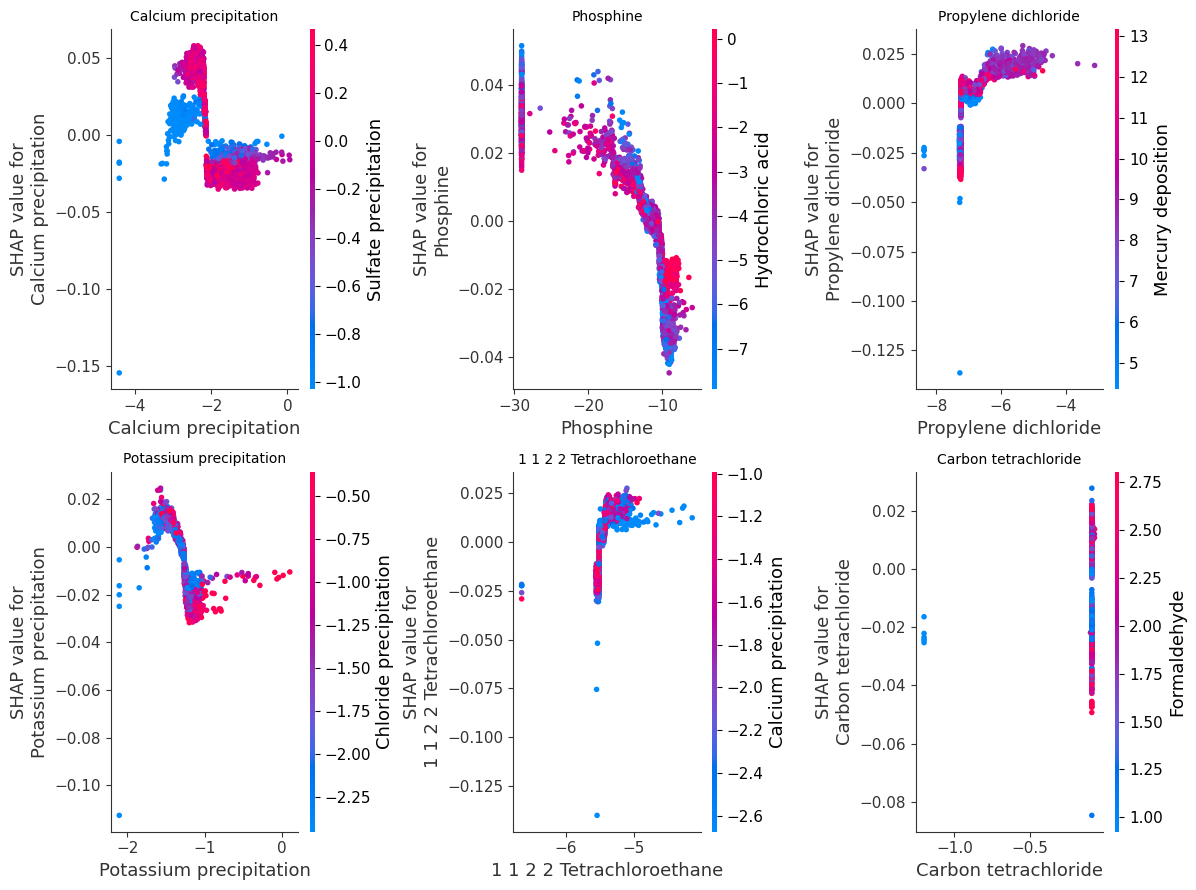

In [22]:
# 13. SHAP dependence plots (top 6 panel)

X_selected_display = X_final.copy()
X_selected_display.columns = [prettify(c) for c in X_selected_display.columns]

top_vars_clean = [prettify(v) for v in top_vars]

fig, axes = plt.subplots(2, 3, figsize=(12, 9))
axes = axes.ravel()

for i, v_clean in enumerate(top_vars_clean):
    if i >= len(axes):
        break
    plt.sca(axes[i])
    shap.dependence_plot(
        ind=v_clean,
        shap_values=shap_values,
        features=X_selected_display,
        interaction_index="auto",
        show=False,
        ax=axes[i],
    )
    axes[i].set_title(v_clean, fontsize=10)
    axes[i].set_xlabel(v_clean)

# Hide any unused axes
for j in range(len(top_vars_clean), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("ASD_shap_dependence_top6_panel.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [23]:
# 14. County-level top SHAP driver

import numpy as np

# Create SHAP dataframe
shap_top12_df = pd.DataFrame(
    shap_values_top12,
    columns=top12_features,
    index=X_final.index
)

# Get top driver (based on absolute SHAP)
top_driver = shap_top12_df.abs().idxmax(axis=1)

# Convert column names to indices
col_idx = shap_top12_df.columns.get_indexer(top_driver)

# Extract corresponding SHAP values
top_shap_value = shap_top12_df.to_numpy()[np.arange(len(shap_top12_df)), col_idx]

# Build final dataframe
result_df = pd.DataFrame({
    "Top_Driver": top_driver,
    "Top_SHAP_Value": top_shap_value
}, index=X_final.index)

# Clean names
result_df["Top_Driver"] = result_df["Top_Driver"].replace({
    "W_EDB_ln": "Ethylene dibromide"
})
result_df["Top_Driver"] = result_df["Top_Driver"].str.replace("_", " ", regex=False)

# Add FIPS AFTER
result_df["FIPS"] = df.loc[X_final.index, "ï»¿FIPS"].values

# Save
result_df[["FIPS", "Top_Driver", "Top_SHAP_Value"]].to_csv(
    "ASD_County_drivers_top12_with_SHAP.csv",
    index=False
)

print(result_df.head())

              Top_Driver  Top_SHAP_Value    FIPS
0   Propylene dichloride       -0.036626  1001.0
1  Calcium precipitation        0.043855  1003.0
2  Calcium precipitation        0.043022  1005.0
3  Calcium precipitation        0.045203  1007.0
4  Calcium precipitation        0.036585  1009.0


In [24]:
# 15. Save model summary & selected features

model_summary = pd.DataFrame({
    "Model":             ["XGBoost-RFE"],
    "Outcome_scale":     ["Logit-transformed ASD prevalence"],
    "Selected_features": [50],
    "R2_mean":           [r2_scores_logit.mean()],
    "R2_sd":             [r2_scores_logit.std()],
    "RMSE_logit_mean":   [rmse_scores_logit.mean()],
    "RMSE_logit_sd":     [rmse_scores_logit.std()],
})

selected_features_df = pd.DataFrame({
    "Selected_Features_50": selected_features_50,
})

model_summary.to_csv("ASD_final_model_summary.csv", index=False)
selected_features_df.to_csv("ASD_selected_features_50.csv", index=False)

print("Saved:")
print("- ASD_final_model_summary.csv")
print("- ASD_selected_features_50.csv")
print("- ASD_top12_SHAP_features.csv")

Saved:
- ASD_final_model_summary.csv
- ASD_selected_features_50.csv
- ASD_top12_SHAP_features.csv
